### Pacotes importados

In [3]:
using LinearAlgebra
using Printf
using Plots

import Pkg
Pkg.add("ForwardDiff")

    Updating registry at `C:\Users\OpAc-BV\.julia\registries\General.toml`
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\OpAc-BV\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\OpAc-BV\.julia\environments\v1.12\Manifest.toml`


## Chapter 10: Newton's local method

### Algorithm 10.1: Newton's local method

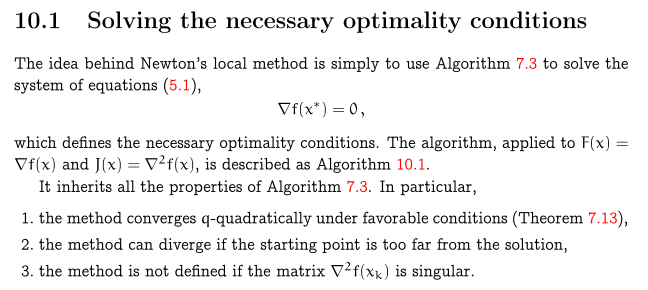

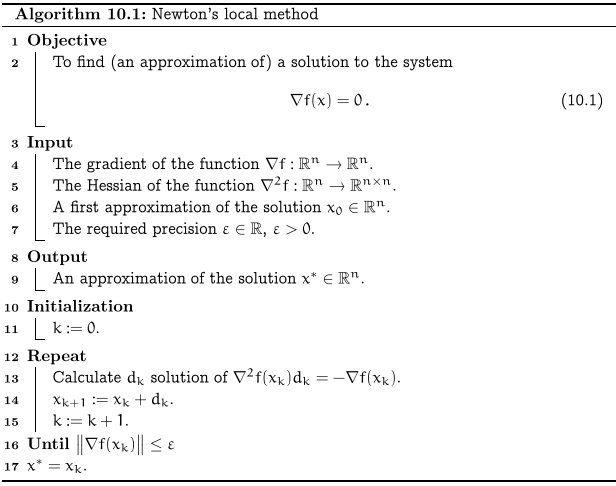

Example 5.8: $f(x_1,x_2) = \frac{1}{2} x_1^2 + x_1 \cos(x_2)$; $x_0 = [1.0, 1.0]$

 k        x1              x2           ||grad||
 0     +1.00000000     +1.00000000  +1.75516512e+00

Gradiente calculado no código:
[1.5403023058681398, -0.8414709848078965]

Hessiana calculada no código:
[1.0 -0.8414709848078965; -0.8414709848078965 -0.5403023058681398]
--------------------------------------------------------------
 1     -0.23384513     +1.36419221  +2.30665382e-01

Gradiente calculado no código:
[-0.02870770271687842, 0.22887198618727408]

Hessiana calculada no código:
[1.0 -0.9787331794267482; -0.9787331794267482 0.04797038772695506]
--------------------------------------------------------------
 2     +0.01081438     +1.58483641  +1.12840545e-02

Gradiente calculado no código:
[-0.003225248070167889, -0.010813309420161909]

Hessiana calculada no código:
[1.0 -0.9999014396308934; -0.9999014396308934 0.00015182975592180622]
--------------------------------------------------------------
 3     -0.00000213     +1.57079327  +2.32349802e-06

Gradiente calculado no códig

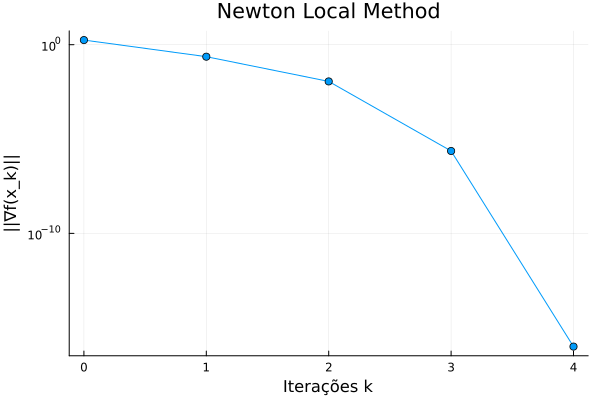

In [5]:

# ÚNICO dado do problema: a função
f(x) = 0.5*x[1]^2 + x[1]*cos(x[2])

# Gradiente calculado 
grad_f(x) = ForwardDiff.gradient(f, x)

# Hessiana calculada
hess_f(x) = ForwardDiff.hessian(f, x)

# Dados iniciais
x = [1.0, 1.0]
epsilon = 1e-15
k = 0
maxiter = 20

ks = Int[]
norms = Float64[]

println("==============================================================")
println(" k        x1              x2           ||grad||")
println("==============================================================")

while k <= maxiter
    g = grad_f(x)
    H = hess_f(x)
    normg = norm(g)

    push!(ks, k)
    push!(norms, max(normg, 1e-16))

    @printf("%2d  %+14.8f  %+14.8f  %+14.8e\n", k, x[1], x[2], normg)

    println("\nGradiente calculado no código:")
    println(g)

    println("\nHessiana calculada no código:")
    println(H)

    println("--------------------------------------------------------------")

    if normg <= epsilon
        break
    end

    # Resolve: H*d = -grad
    d = H \ (-g)

    x = x + d
    k += 1
end

println("\nSolução aproximada:")
println("x* = ", x)
println("f(x*) = ", f(x))
println("grad(x*) = ", grad_f(x))
println("Hessiana em x* = ")
println(hess_f(x))
println("||grad(x*)|| = ", norm(grad_f(x)))

plot(
    ks,
    norms,
    marker = :circle,
    xlabel = "Iterações k",
    ylabel = "||∇f(x_k)||",
    title = "Newton Local Method",
    legend = false,
    yscale = :log10
)

### Algorithm 10.2: Newton's local method by quadratic modeling

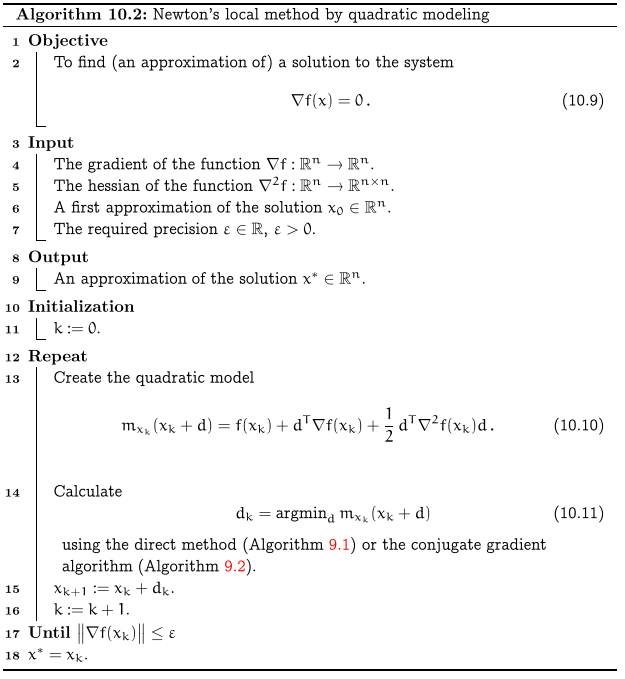

We test the algorithm on the Rosenbrock function. It is described in Section 11.6 of the book for two variables.  The implementation below involves $n$ variables: \\[f(x) = \sum_{i=1}^{n-1} f_i(x) = \sum_{i=1}^{n-1} 100 (x_{i+1}-x_i^2)^2 + (1-x_i)^2.\\]
The calculation of the derivatives is based on the partial derivatives of the functions $f_i$:
\\[
\begin{array}{rcl}
\partial f_i/\partial x_i&=& -400 x_i (x_{i+1}-x_i^2) - 2(1-x_i), \\\\
\partial f_i/\partial x_{i+1}&=& 200 (x_{i+1}-x_i^2), \\\\
\partial^2 f_i/\partial x^2_i  &=& -400 x_{i+1}+ 1200 x_i^2 + 2, \\\\
\partial^2 f_i/\partial x_i \partial x_{i+1}  &=& -400 x_i^2, \\\\
\partial^2 f_i/\partial x^2_{i+1}  &=& 200. 
\end{array}
\\]

 k        x                ||grad||
 0   [-1.2, 1.0]   2.328677e+02
 1   [-1.1752808988764045, 1.3806741573033707]   4.639426e+00
 2   [0.7631148711763358, -3.175033854747881]   1.370790e+03
 3   [0.7634296788839403, 0.5828247754969436]   4.731104e-01
 4   [0.9999953110849832, 0.9440273238532731]   2.502745e+01
 5   [0.9999956956536618, 0.9999913913257031]   8.608634e-06
 6   [0.9999999999999999, 0.9999999999814724]   8.285706e-09

Solução aproximada:
x* = [0.9999999999999999, 0.9999999999814724]
f(x*) = 3.4326461875363225e-20
||grad|| = 8.285705791275365e-9


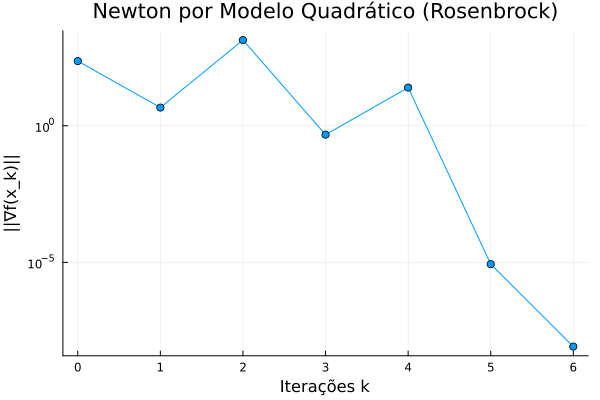

In [6]:
# Função de Rosenbrock (genérica)
function f(x)
    n = length(x)
    s = 0.0
    for i in 1:n-1
        s += 100*(x[i+1] - x[i]^2)^2 + (1 - x[i])^2
    end
    return s
end

# Gradiente automático
grad_f(x) = ForwardDiff.gradient(f, x)

# Hessiana automática
hess_f(x) = ForwardDiff.hessian(f, x)

# Ponto inicial (clássico Rosenbrock)
x = [-1.2, 1.0]   # pode mudar dimensão aqui

epsilon = 1e-8
k = 0
maxiter = 50

ks = Int[]
norms = Float64[]

println("==============================================================")
println(" k        x                ||grad||")
println("==============================================================")

while k <= maxiter
    g = grad_f(x)
    H = hess_f(x)
    normg = norm(g)

    push!(ks, k)
    push!(norms, max(normg, 1e-16))

    @printf("%2d   %s   %.6e\n", k, string(x), normg)

    if normg <= epsilon
        break
    end

    # 🔥 Modelo quadrático → resolver:
    # min d  f(x_k) + gᵀ d + 1/2 dᵀ H d
    # → solução: H d = -g

    d = H \ (-g)

    x = x + d
    k += 1
end

println("\nSolução aproximada:")
println("x* = ", x)
println("f(x*) = ", f(x))
println("||grad|| = ", norm(grad_f(x)))

plot(
    ks,
    norms,
    marker = :circle,
    xlabel = "Iterações k",
    ylabel = "||∇f(x_k)||",
    title = "Newton por Modelo Quadrático (Rosenbrock)",
    legend = false,
    yscale = :log10
)

We now apply the algorithm on example 5.8. In this case, the algorithm fails to converge, and one hessian is not positive definite. We try first using the direct method to solve the quadratic problem. An error is triggered. 

In [11]:
# Example 5.8
f(x) = 0.5*x[1]^2 + x[1]*cos(x[2])

grad_f(x) = ForwardDiff.gradient(f, x)
hess_f(x) = ForwardDiff.hessian(f, x)

x = [1.0, 1.0]
epsilon = 1e-15
maxiter = 20
k = 0

@printf("%3s %18s %18s %18s\n", "k", "x1", "x2", "||grad||")

while k <= maxiter
    g = grad_f(x)
    H = hess_f(x)
    normg = norm(g)

    @printf("%3d %+18.10E %+18.10E %+18.10E\n", k, x[1], x[2], normg)

    if normg <= epsilon
        break
    end

    # Direct method for quadratic problem:
    # requires Hessian positive definite
    try
        C = cholesky(H)
        d = C \ (-g)
    catch
        println("Hessian is not positive definite. Direct method failed.")
break
    end

    x = x + d
    k += 1
end

println("\nFinal result:")
println("x = ", x)
println("f(x) = ", f(x))
println("grad = ", grad_f(x))
println("Hessian = ")
println(hess_f(x))

  k                 x1                 x2           ||grad||
  0  +1.0000000000E+00  +1.0000000000E+00  +1.7551651238E+00
Hessian is not positive definite. Direct method failed.

Final result:
x = [1.0, 1.0]
f(x) = 1.0403023058681398
grad = [1.5403023058681398, -0.8414709848078965]
Hessian = 
[1.0 -0.8414709848078965; -0.8414709848078965 -0.5403023058681398]


If we try with the conjugate gradient method, an error is also triggered. 

In [9]:

f(x) = 0.5*x[1]^2 + x[1]*cos(x[2])

grad_f(x) = ForwardDiff.gradient(f, x)
hess_f(x) = ForwardDiff.hessian(f, x)

x = [1.0, 1.0]
epsilon = 1e-15
maxiter = 20
k = 0

@printf("%3s %18s %18s %18s\n", "k", "x1", "x2", "||grad||")

while k <= maxiter
    g = grad_f(x)
    H = hess_f(x)
    normg = norm(g)

    @printf("%3d %+18.10E %+18.10E %+18.10E\n", k, x[1], x[2], normg)

    if normg <= epsilon
        break
    end

    # Conjugate Gradient requires H symmetric positive definite
    try
        cholesky(H)
    catch
        println("Hessian is not positive definite. Conjugate Gradient method failed.")
break
    end

    # If H were positive definite, CG could be applied here
    d = H \ (-g)

    x = x + d
    k += 1
end

  k                 x1                 x2           ||grad||
  0  +1.0000000000E+00  +1.0000000000E+00  +1.7551651238E+00
Hessian is not positive definite. Conjugate Gradient method failed.
